# Comparatif des trois méthodes de réseau cyclable

Trois méthodes ont été essayées pour construire le jeu de données du réseau cyclable :

    00_methode_primitive/   filtre à règles écrites à la main - testé sur Lyon/Grenoble, abandonné
    01_geovelo_seul/        le réseau GéoVélo tel quel, sans OpenStreetMap - incomplet
    02_FOB/                 OpenStreetMap + modèle appris - LA MÉTHODE RETENUE

Ce notebook compare `01_geovelo_seul` et `02_FOB` sur les vrais chiffres (vendorisés, voir
`reference.py`) - `00_methode_primitive` n'est pas comparable ici : elle n'a jamais tourné à l'échelle
de la France (voir son README, testée seulement sur une petite zone).

## 0. Charger la table de référence — [`reference.py`](reference.py)

In [1]:
import sys
from pathlib import Path

ICI = Path.cwd()
sys.path.insert(0, str(ICI))
RACINE = ICI.parents[1]

import pandas as pd
pd.set_option("display.width", 160)

from reference import SCENARIOS, charger_reference, longueur_effective, totaux_nationaux

FICHIER_REFERENCE = RACINE / "data" / "donnees_brutes" / "reference" / "longueurs_reseau_reference.csv"
reference = charger_reference(FICHIER_REFERENCE)
print(f"{len(reference):,} lignes (commune, année), {reference['annee'].nunique()} années")
reference.head(3)

91,682 lignes (commune, année), 7 années


,annee,code_commune,nom_commune,code_departement,len_d_GV,len_g_GV,len_d_FOB,len_g_FOB,len_d_FOB_AM,len_g_FOB_AM
0,2019,01004,Ambérieu-en-Bugey,01,7.3767,7.3767,5.124262,5.124262,5.124262,5.124262
1,2019,01007,Ambronay,01,2.7404,2.7404,0.562431,0.562431,0.562431,0.562431
2,2019,01008,Ambutrix,01,0.0911,0.0911,0.091044,0.091044,0.000000,0.000000


## 1. Linéaire national par année et par scénario

GV (GéoVélo seul), FOB (tout le réseau prédit), FOB_AM (FOB restreint aux aménagements dédiés - voir
`02_FOB/etiquettes.py`).

In [2]:
totaux = totaux_nationaux(reference)
totaux

,GV,FOB,FOB_AM
annee,,,
2019,120528.0,86667.0,74748.0
2020,120528.0,96458.0,83522.0
2021,124680.0,104305.0,89511.0
2022,106731.0,111398.0,95106.0
2023,114149.0,119164.0,101427.0
2024,126397.0,126642.0,107687.0
2025,134584.0,134594.0,113910.0


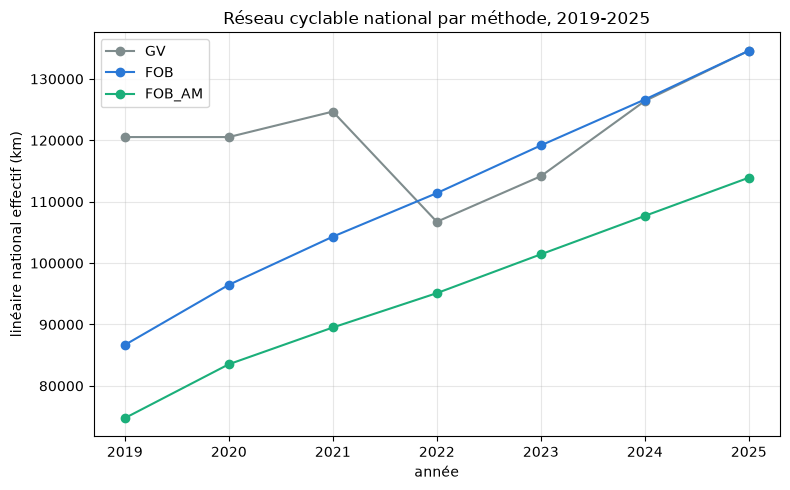

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for scenario, couleur in zip(SCENARIOS, ["#7f8c8d", "#2a78d6", "#1baf7a"]):
    ax.plot(totaux.index, totaux[scenario], marker="o", label=scenario, color=couleur)
ax.set_ylabel("linéaire national effectif (km)")
ax.set_xlabel("année")
ax.set_title("Réseau cyclable national par méthode, 2019-2025")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 2. FOB dépasse-t-il GéoVélo seul, et quand ?

OpenStreetMap capte des aménagements que GéoVélo n'a pas (encore) numérisés - et l'inverse est vrai
aussi (un tronçon dans GéoVélo mais absent/mal tagué sur OSM). Le solde net :

In [4]:
totaux["FOB_moins_GV"] = totaux["FOB"] - totaux["GV"]
totaux["FOB_moins_GV_pct"] = (totaux["FOB_moins_GV"] / totaux["GV"]).map("{:+.1%}".format)
totaux[["GV", "FOB", "FOB_moins_GV", "FOB_moins_GV_pct"]]

,GV,FOB,FOB_moins_GV,FOB_moins_GV_pct
annee,,,,
2019,120528.0,86667.0,-33861.0,-28.1%
2020,120528.0,96458.0,-24070.0,-20.0%
2021,124680.0,104305.0,-20375.0,-16.3%
2022,106731.0,111398.0,4667.0,+4.4%
2023,114149.0,119164.0,5015.0,+4.4%
2024,126397.0,126642.0,245.0,+0.2%
2025,134584.0,134594.0,10.0,+0.0%


## 3. Où l'écart FOB / GéoVélo est-il le plus marqué (2024) ?

Les 10 communes où FOB trouve le plus de réseau EN PLUS de ce que GéoVélo a numérisé - candidates à
vérifier en premier si l'écart semble anormal.

In [5]:
reference_2024 = reference[reference["annee"] == 2024].copy()
for s in SCENARIOS:
    reference_2024[s] = longueur_effective(reference_2024, s)
reference_2024["ecart_FOB_GV"] = reference_2024["FOB"] - reference_2024["GV"]
reference_2024.nlargest(10, "ecart_FOB_GV")[["code_commune", "nom_commune", "code_departement", "GV", "FOB", "ecart_FOB_GV"]]

,code_commune,nom_commune,code_departement,GV,FOB,ecart_FOB_GV
77850,93066,Saint-Denis,93,135.6127,177.091680,41.478980
74679,69149,Oullins-Pierre-Bénite,69,38.5112,63.287006,24.775806
70923,49126,Orée d'Anjou,49,0.0000,22.946172,22.946172
73294,62447,Hesdin-la-Forêt,62,0.3076,15.914429,15.606829
67579,25390,Pays-de-Montbenoît,25,2.9140,17.050506,14.136506
66098,11420,Villebazy,11,0.0000,13.502869,13.502869
66079,11344,Saint-Hilaire,11,0.0000,13.028671,13.028671
77112,85289,Terval,85,0.8764,12.706180,11.829780
75144,72195,Mézeray,72,0.0000,10.851660,10.851660
75137,72179,Malicorne-sur-Sarthe,72,0.0000,10.456745,10.456745


## Conclusion

FOB est la méthode retenue pour la suite du projet (`02_FOB/`, puis les étapes 04 et après) : elle
couvre toute la France (contrairement à `00_methode_primitive`, jamais passée à l'échelle), et son
linéaire dépasse GéoVélo seul dès 2024 tout en restant proche les autres années - signe qu'elle
capture du réseau réel sans sur-inclure massivement (voir les métriques de validation du modèle,
`02_FOB/README.md`).